In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import time
from torch.optim.lr_scheduler import StepLR

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def generate(time, cases, mag=1):#, noise=0.1):
    amp = torch.rand(cases, 1, 1) * mag
    freq = torch.rand(cases, 1, 1) * mag
    phase = torch.rand(cases, 1, 1) * mag

    coeffs = torch.stack((amp, freq, phase))
    coeffs = torch.atleast_2d(coeffs)
    coeffs = torch.transpose(coeffs, 0, 1)
    coeffs = torch.transpose(coeffs, 1, 2)

    x = torch.cat(coeffs.shape[0] * [time]).reshape(coeffs.shape[0], -1)
    x = torch.transpose(x, 0, 1)
    y =  coeffs[:,0,0,0] * torch.sin(2 * torch.pi * coeffs[:,0,1,0] * x + coeffs[:,0,2,0])
    out = torch.zeros((coeffs.shape[0], time.shape[0],1, 1))
    out[:, :, 0, 0] = torch.transpose(y, 0, 1)
    return torch.sum(out, dim=3)
    

In [4]:
time = torch.linspace(0, 1, 1000)
cases = 10000

consumption = generate(time, cases) # household energy consumption 0 - 1.5 kW
gridLoad = generate(time, cases) # grid energy consumption 0 - 500 kW
conditions = generate(time, cases) # quality of conditions for energy generation 0 - 1

engergyGenerated = conditions * 0.6 # <== 0.6 baseline efficenecy of generation 
energyCost = gridLoad / 500 * 0.25 # <== 500 demand, 0.25 baseline price kW/hour

In [5]:
print(consumption.shape)
print(gridLoad.shape)
print(conditions.shape)
print(engergyGenerated.shape)
print(energyCost.shape)

torch.Size([10000, 1000, 1])
torch.Size([10000, 1000, 1])
torch.Size([10000, 1000, 1])
torch.Size([10000, 1000, 1])
torch.Size([10000, 1000, 1])


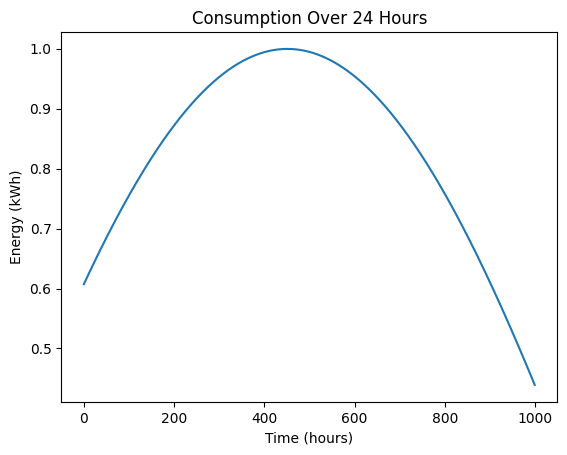

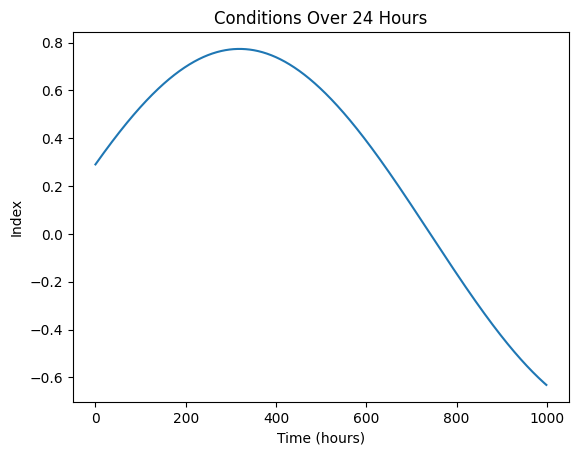

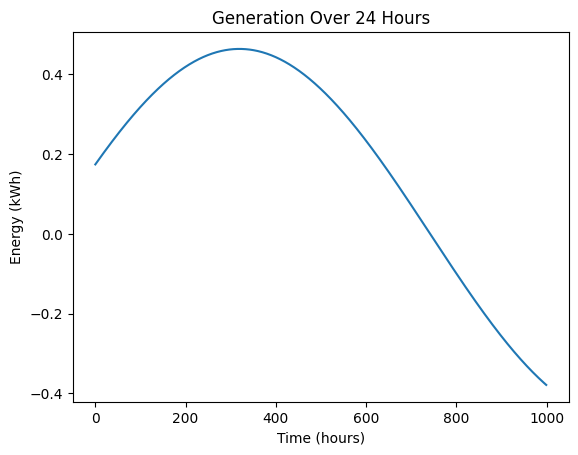

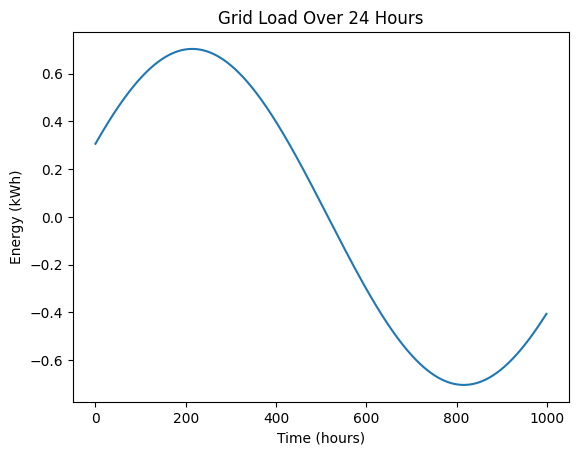

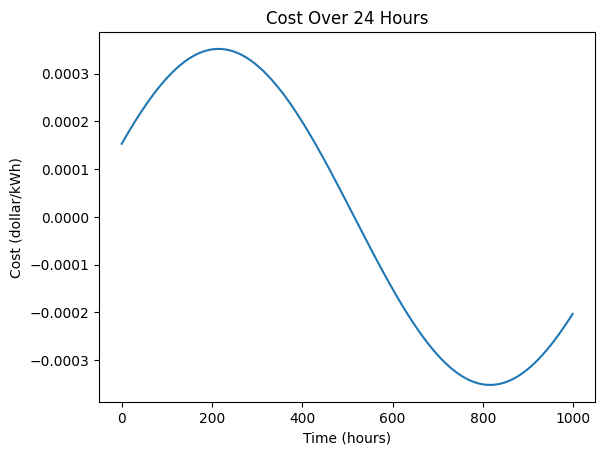

In [6]:
r = np.random.randint(cases)

plt.plot(consumption[r, :].numpy())
plt.title('Consumption Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Energy (kWh)')
plt.show()

plt.plot(conditions[r, :].numpy())
plt.title('Conditions Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Index')
plt.show()

plt.plot(engergyGenerated[r, :].numpy())
plt.title('Generation Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Energy (kWh)')
plt.show()

plt.plot(gridLoad[r, :].numpy())
plt.title('Grid Load Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Energy (kWh)')
plt.show()

plt.plot(energyCost[r, :].numpy())
plt.title('Cost Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Cost (dollar/kWh)')
plt.show()

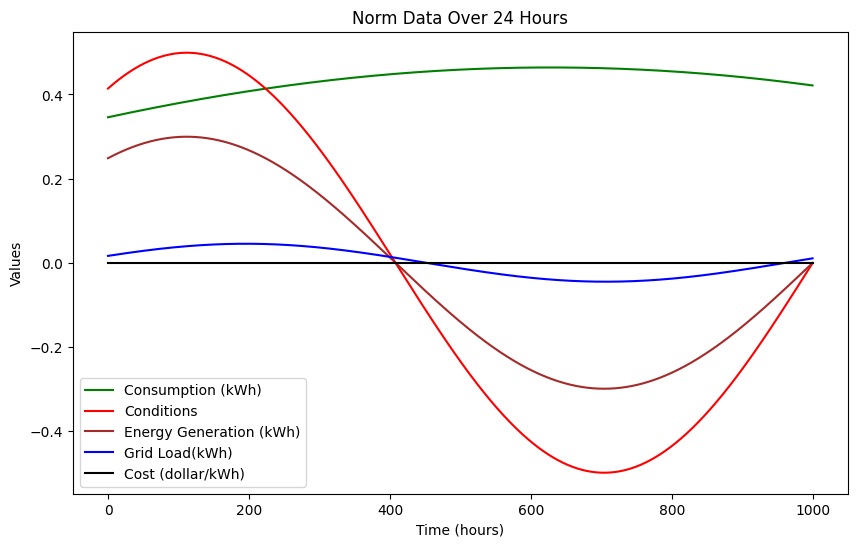

In [19]:
r = np.random.randint(cases)

plt.figure(figsize=(10, 6))
plt.plot(consumption[r, :].numpy(), label="Consumption (kWh)", color='green')
plt.plot(conditions[r, :].numpy(), label="Conditions", color='red')
plt.plot(engergyGenerated[r, :].numpy(), label="Energy Generation (kWh)", color='brown')
plt.plot(gridLoad[r, :].numpy(), label="Grid Load(kWh)", color='blue')
plt.plot(energyCost[r, :].numpy(), label="Cost (dollar/kWh)", color='black')
plt.title('Norm Data Over 24 Hours')
plt.xlabel('Time (hours)')
plt.ylabel('Values')
plt.legend()

plt.show()

In [21]:
stackedData = torch.stack((consumption, conditions, gridLoad), dim=1).reshape(int(cases * 3), -1).unsqueeze(2)
print(stackedData.shape)
dataloader = DataLoader(stackedData, batch_size=500, shuffle=True)

torch.Size([30000, 1000, 1])


In [27]:
class GeneralModel(nn.Module):
    def __init__(self, x_data, device):
        super().__init__()
        self.device = device
        self.x_data = x_data.to(self.device)

        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=8, kernel_size=7),
            nn.SELU(),
            nn.Conv1d(in_channels=8, out_channels=6, kernel_size=7),
            nn.SELU(),
            nn.Conv1d(in_channels=6, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(64)
        )

        self.block2 = nn.Sequential(
            nn.Linear(256, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 20),
            nn.SELU(),
        )

        self.block3 = nn.Sequential(
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=2, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(in_channels=4, out_channels=4, kernel_size=5),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(16),
            nn.Conv1d(in_channels=4, out_channels=2, kernel_size=3),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(8),
            nn.Conv1d(in_channels=2, out_channels=2, kernel_size=3),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(4),
        )

        self.flatten_layer = nn.Flatten()

        self.embedBlock = nn.Sequential(
            nn.Linear(28, 128),
            nn.SELU(),
            nn.Linear(128, 64),
            nn.SELU(),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        x = torch.swapaxes(x, 1, 2).to(self.device)
        x = self.block1(x)
        x2 = torch.reshape(x, (-1, 256))
        x2 = self.block2(x2)
        x = torch.reshape(x, (-1, 2, 128))
        x = self.block3(x)
        x = self.flatten_layer(x)
        x3 = torch.cat((x, x2), 1)
        embedding = self.embedBlock(x3)
        amp = embedding[:, 0].type(torch.float).unsqueeze(1).to(self.device)
        freq = embedding[:, 1].type(torch.float).unsqueeze(1).to(self.device)
        phase = embedding[:, 2].type(torch.float).unsqueeze(1).to(self.device)
        
        return amp * torch.sin(2 * torch.pi * freq * self.x_data.to(self.device) + phase), amp, freq, phase

In [28]:
model = GeneralModel(x_data=time, device=device).to(device)
lossFunc = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)

In [34]:
epochs = 50
for epoch in range(epochs):
    trainLoss = 0.0
    totalNum = 0
    model.train()

    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds, amp, freq, phase = model(batch)
        loss = lossFunc(preds,batch.squeeze(2))
        loss.backward()
        optimizer.step()
        trainLoss += loss.item() * preds.shape[0]
        totalNum += preds.shape[0]
    scheduler.step()
    trainLoss /= totalNum
    print(f"epoch : {epoch}/{epochs}, loss = {trainLoss:.8f}")

epoch : 0/50, loss = 0.00337336
epoch : 1/50, loss = 0.00337336
epoch : 2/50, loss = 0.00337335
epoch : 3/50, loss = 0.00337335
epoch : 4/50, loss = 0.00337335
epoch : 5/50, loss = 0.00337335
epoch : 6/50, loss = 0.00337335
epoch : 7/50, loss = 0.00337335
epoch : 8/50, loss = 0.00337335
epoch : 9/50, loss = 0.00337334
epoch : 10/50, loss = 0.00337334
epoch : 11/50, loss = 0.00337334
epoch : 12/50, loss = 0.00337334
epoch : 13/50, loss = 0.00337334
epoch : 14/50, loss = 0.00337334
epoch : 15/50, loss = 0.00337334
epoch : 16/50, loss = 0.00337334
epoch : 17/50, loss = 0.00337334
epoch : 18/50, loss = 0.00337334
epoch : 19/50, loss = 0.00337334
epoch : 20/50, loss = 0.00337334
epoch : 21/50, loss = 0.00337334
epoch : 22/50, loss = 0.00337334
epoch : 23/50, loss = 0.00337334
epoch : 24/50, loss = 0.00337334
epoch : 25/50, loss = 0.00337334
epoch : 26/50, loss = 0.00337334
epoch : 27/50, loss = 0.00337334
epoch : 28/50, loss = 0.00337334
epoch : 29/50, loss = 0.00337334
epoch : 30/50, loss 

In [35]:
t_x_values = torch.linspace(0, 1, 1000)
t_y_values = generate(time, cases)

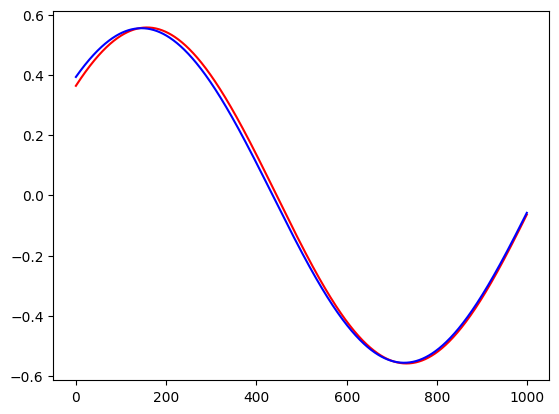

In [48]:
preds, amp, freq, phase = model(t_y_values)
rand = np.random.randint(0, 1000)
plt.plot(preds[rand].detach().cpu().numpy(), "r", label='Predicted')
plt.plot(t_y_values[rand].detach().cpu().numpy(), "b", label='True')

In [52]:
def eval(a, f, p, x):
    return a.to(device) * torch.sin(2 * torch.pi * f.to(device) * x.to(device) + p.to(device))

In [56]:
sampleConsumption = generate(time, 1000)
sampleGridLoad = generate(time, 1000)
sampleConditions = generate(time, 1000)

consPred, consAmp, consFreq, consPhase = model(sampleConsumption)
loadPred, loadAmp, loadFreq, loadPhase = model(sampleGridLoad)
condPred, condAmp, condFreq, condPhase = model(sampleConditions)

testConsumption = eval(consAmp, consFreq, consPhase, time)
testLoad = eval(loadAmp, loadFreq, loadPhase, time)
testCondititions = eval(condAmp, condFreq, condPhase, time)


testEngergyGenerated = testCondititions * 0.6 # <== 0.6 baseline efficenecy of generation 
testEnergyCost = testLoad / 500 * 0.25 # <== 500 demand, 0.25 baseline price kW/hour

print(testConsumption.shape)
print(testEngergyGenerated.shape)
print(testEnergyCost.shape)

torch.Size([1000, 1000])
torch.Size([1000, 1000])
torch.Size([1000, 1000])


In [76]:
def optimization(consumption, generation, cost):
    renewableUsed = torch.minimum(consumption, generation)
    surplus = torch.clamp(generation - consumption, min=0)
    deficit = torch.clamp(consumption - generation, min=0)
    battery = 0
    gridPurchases = torch.zeros_like(cost)
    gridUsage = torch.zeros_like(deficit)
    battery += surplus.sum().item()
    remainingDeficit = deficit.clone()
    for t in torch.argsort(cost, descending=False):
        if battery <= 0:
            break
        fillAmount = min(battery, remainingDeficit[t])
        gridUsage[t] = fillAmount
        remainingDeficit[t] -= fillAmount
        battery -= fillAmount
    totalRemaining = remainingDeficit.sum().item()
    if totalRemaining > 0:
        sortedTimes = torch.argsort(cost)
        for t in sortedTimes:
            purchaseAmount = min(totalRemaining, consumption[t].item())
            gridPurchases[t] += purchaseAmount
            totalRemaining -= purchaseAmount
            if totalRemaining <= 0:
                break
    totalCost = (gridPurchases * cost).sum()
    return {
        'renewableUsed': renewableUsed,
        'gridUsed': gridUsage + remainingDeficit,
        'storageUsed': gridUsage,
        'gridPurchases': gridPurchases,
        'totalCost': totalCost,
        'costBreakdown': {
            'renewablePercent': renewableUsed.sum() / consumption.sum(),
            'storagePercent': gridUsage.sum() / consumption.sum(),
            'gridPercent': remainingDeficit.sum() / consumption.sum()
        }
    }

In [77]:
case = np.random.randint(0, 1000)
results = optimization(testConsumption[case], testEngergyGenerated[case], testEnergyCost[case])

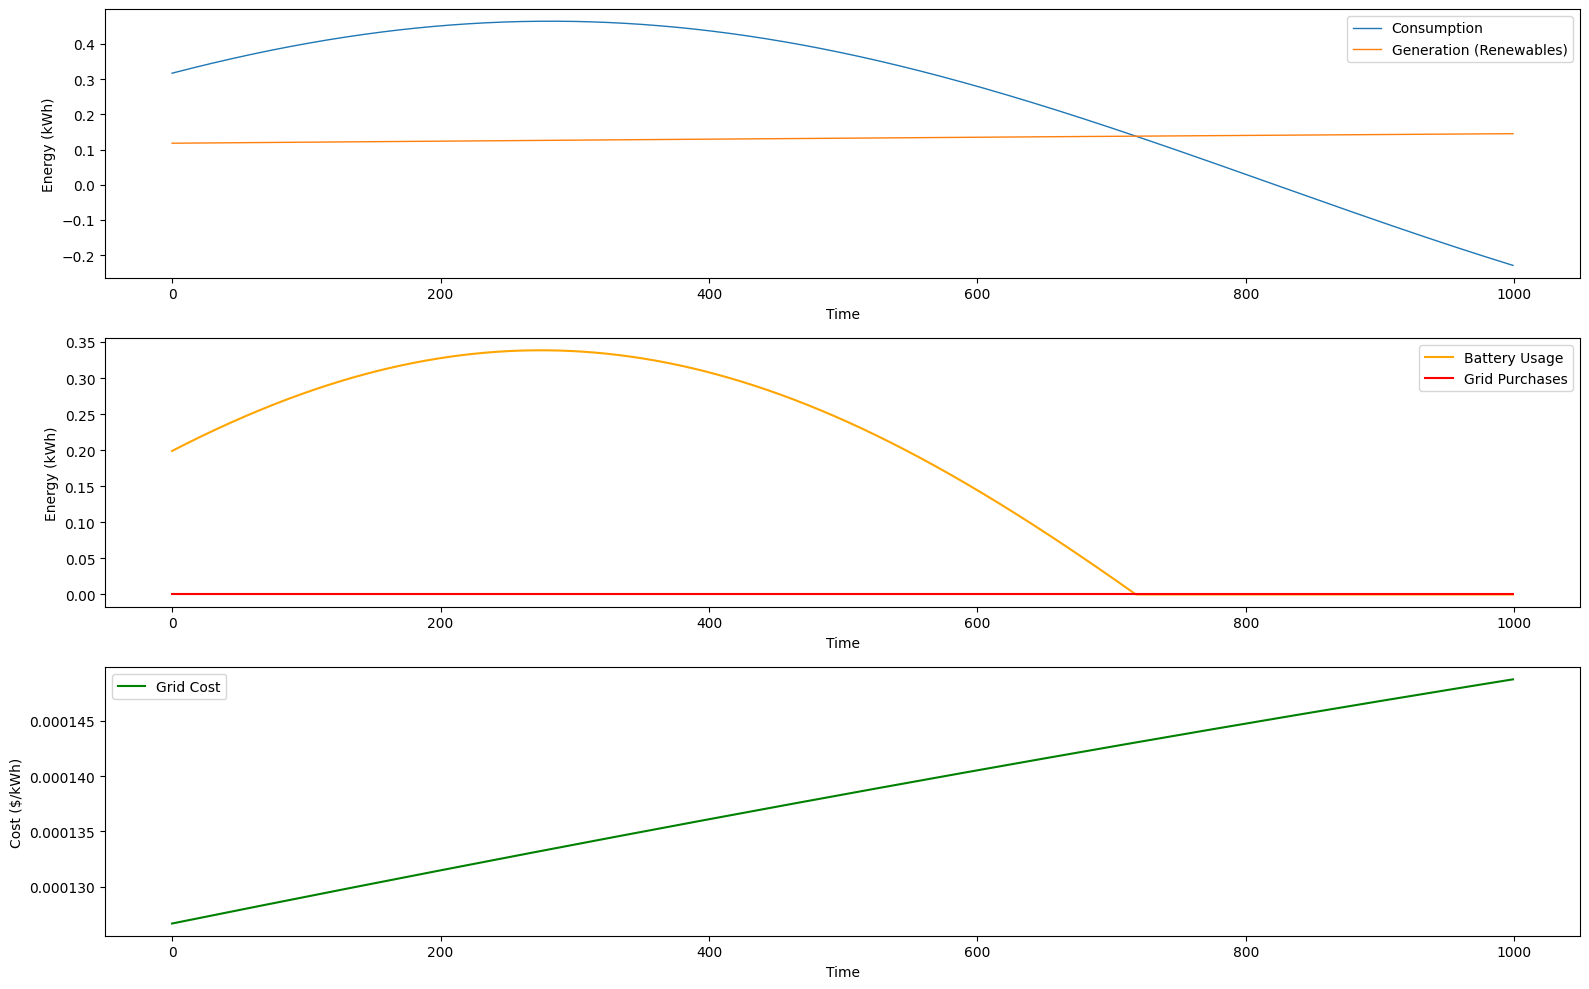

In [84]:
plt.figure(figsize=(16, 10))

plt.subplot(3, 1, 1)
plt.plot(testConsumption[case].detach().cpu().numpy(), label="Consumption", linewidth=1)
plt.plot(testEngergyGenerated[case].detach().cpu().numpy(), label="Generation (Renewables)", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(results['storageUsed'].detach().cpu().numpy(), label="Battery Usage", color='orange')
plt.plot(results['gridPurchases'].detach().cpu().numpy(), label="Grid Purchases", color='red')
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(testEnergyCost[case].detach().cpu().numpy(), label="Grid Cost", color='green')
plt.xlabel("Time")
plt.ylabel("Cost ($/kWh)")
plt.legend()

plt.tight_layout()
plt.show()

summary = {
    "Total Consumption": testConsumption[case].sum().item(),
    "Total Generation": testEngergyGenerated[case].sum().item(),
    "Renewable Used": results['renewableUsed'].sum().item(),
    "Battery (Storage) Used": results['storageUsed'].sum().item(),
    "Grid Purchases": results['gridPurchases'].sum().item(),
    "Total Cost ($)": results['totalCost'].item(),
    "Breakdown (%)": {
        k: f"{(v.item() * 100):.2f}%" for k, v in results['costBreakdown'].items()
    }
}